# QuantumEdge - Phase 3 Data Builder
Creates `data/market_data.csv` for `QuantumEdge_Phase3_QRC.ipynb`.

Run this **once** (top to bottom), then **commit `data/market_data.csv`**. The main notebook reads that committed
file, so judges reproduce the exact input with no live download. Columns produced: `ret` (log return),
`rv` (Garman-Klass realized-variance proxy), `vix` (CBOE VIX close).

Source: public S&P 500 (`^GSPC`) and VIX (`^VIX`) daily OHLC via `yfinance`. The Oxford-Man Realized Library was
discontinued in 2023, so we rebuild the target from public daily OHLC instead.

### 1. Setup - install dependencies into this kernel

In [1]:
import importlib.util, subprocess, sys
_need = {"pandas":"pandas","numpy":"numpy","yfinance":"yfinance","matplotlib":"matplotlib"}
_missing = [pip for mod,pip in _need.items() if importlib.util.find_spec(mod) is None]
if _missing:
    print("installing:", _missing)
    subprocess.run([sys.executable,"-m","pip","install","--quiet",*_missing], check=True)
else:
    print("all dependencies present")

installing: ['pandas', 'yfinance', 'matplotlib']


### 2. Configuration

In [2]:
import os, numpy as np, pandas as pd
TICKER, VIX = "^GSPC", "^VIX"
START, END  = "2010-01-01", "2025-01-01"
OUT = "data/market_data.csv"
os.makedirs("data", exist_ok=True)
print(f"{TICKER} + {VIX} | {START} -> {END} | out: {OUT}")

^GSPC + ^VIX | 2010-01-01 -> 2025-01-01 | out: data/market_data.csv


### 3. Download and build the dataset
Garman-Klass daily variance:  $\hat{\sigma}^2_{GK} = 0.5\,(\ln H/L)^2 - (2\ln 2 - 1)(\ln C/O)^2$

In [3]:
import yfinance as yf

def flat(df):
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df

def garman_klass(px):
    o,h,l,c = np.log(px["Open"]), np.log(px["High"]), np.log(px["Low"]), np.log(px["Close"])
    return (0.5*(h-l)**2 - (2*np.log(2)-1)*(c-o)**2).clip(lower=1e-10)

px = flat(yf.download(TICKER, start=START, end=END, auto_adjust=False, progress=False))
vx = flat(yf.download(VIX,    start=START, end=END, auto_adjust=False, progress=False))
assert not px.empty, "OHLC download failed - check network/ticker"

df = pd.DataFrame(index=px.index)
df["ret"] = np.log(px["Close"]).diff()
df["rv"]  = garman_klass(px)
df["vix"] = vx["Close"].reindex(px.index).ffill()
df = df.dropna()
print(f"built {len(df)} rows | {df.index[0].date()} -> {df.index[-1].date()}")
df.head()

built 3773 rows | 2010-01-05 -> 2024-12-31


,ret,rv,vix
Date,,,
2010-01-05,0.003111,0.000014,19.350000
2010-01-06,0.000545,0.000010,19.160000
2010-01-07,0.003993,0.000039,19.059999
2010-01-08,0.002878,0.000026,18.129999
2010-01-11,0.001745,0.000022,17.549999


### 4. Write the CSV

In [4]:
df.to_csv(OUT)
print(f"wrote {OUT} ({len(df)} rows). COMMIT THIS FILE so judges reproduce the exact input.")

wrote data/market_data.csv (3773 rows). COMMIT THIS FILE so judges reproduce the exact input.


### 5. Verify and preview
Reload exactly as the main notebook does, and plot the realized-variance series as a sanity check.

reload OK | columns: ['ret', 'rv', 'vix'] | rows: 3773
               ret           rv          vix
count  3773.000000  3773.000000  3773.000000
mean      0.000437     0.000063    18.376117
std       0.010889     0.000141     6.963801
min      -0.127652     0.000001     9.140000
25%      -0.003813     0.000013    13.600000
50%       0.000676     0.000028    16.600000
75%       0.005674     0.000063    21.160000
max       0.089683     0.003774    82.690002


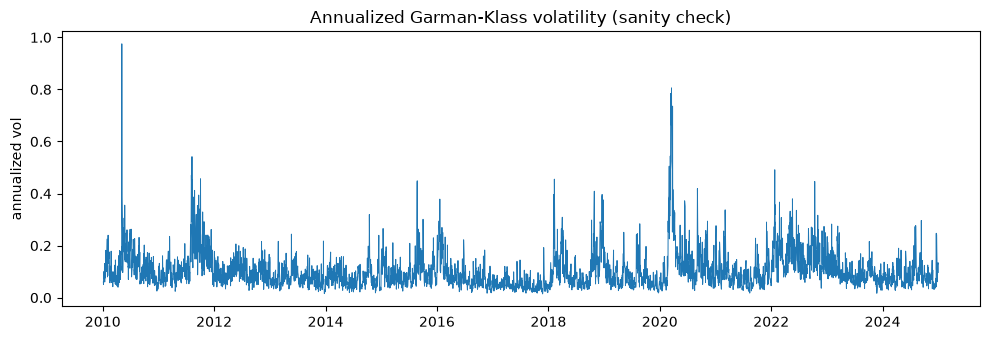

In [5]:
import matplotlib.pyplot as plt
chk = pd.read_csv(OUT, index_col=0, parse_dates=True)
assert list(chk.columns) == ["ret","rv","vix"], f"unexpected columns: {list(chk.columns)}"
print("reload OK | columns:", list(chk.columns), "| rows:", len(chk))
print(chk.describe().round(6))

fig, ax = plt.subplots(figsize=(10,3.5))
ax.plot(chk.index, np.sqrt(chk["rv"]*252), lw=0.7)
ax.set_title("Annualized Garman-Klass volatility (sanity check)")
ax.set_ylabel("annualized vol"); fig.tight_layout(); plt.show()